LOAD THE DATASET

In [9]:
import pandas as pd
df=pd.read_csv("c:\\Users\\admin\\Downloads\\archive (1)\\Housing.csv.csv")
print(df.head(5))
print(df.shape)
print(df.info())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
(13320, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  obj

Null value analysis

In [10]:
missingval_sum=df.isnull().sum()
missingval_percent=df.isnull().sum()/len(df)*100
print(f"missng values sum:{missingval_sum} ")
print(f"total missng values in percentage {missingval_percent}")

missng values sum:area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64 
total missng values in percentage area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64


In [20]:
missing_df = pd.DataFrame({
    "missing_sum":missingval_sum,
    "missing_percent":missingval_percent
})
print(missing_df)

              missing_sum  missing_percent
area_type               0         0.000000
availability            0         0.000000
location                1         0.007508
size                   16         0.120120
society              5502        41.306306
total_sqft              0         0.000000
bath                   73         0.548048
balcony               609         4.572072
price                   0         0.000000


In [23]:
# column exceed a 20% null rate.
more_than_20 = missing_df[missing_df["missing_percent"] > 20]
print(f"Columns with more than 20% missing values: {more_than_20}")

Columns with more than 20% missing values:          missing_sum  missing_percent
society         5502        41.306306


In [60]:
numeric_cols = df.select_dtypes(include=["number"]).columns

In [62]:
for col in numeric_cols:
    if missingval_percent[col] < 20:
        df[col].fillna(df[col].median(), inplace=True)
        


Duplicate detection and removal

In [29]:
duplicates=df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicates}")

Total number of duplicate rows: 530


In [31]:
print(df[df.duplicated()])

                  area_type   availability          location       size  \
971    Super built-up  Area  Ready To Move      Haralur Road      3 BHK   
1115   Super built-up  Area  Ready To Move      Haralur Road      2 BHK   
1143   Super built-up  Area  Ready To Move       Vittasandra      2 BHK   
1290   Super built-up  Area  Ready To Move      Haralur Road      2 BHK   
1394   Super built-up  Area  Ready To Move      Haralur Road      2 BHK   
...                     ...            ...               ...        ...   
13285  Super built-up  Area  Ready To Move      VHBCS Layout      2 BHK   
13299  Super built-up  Area         18-Dec        Whitefield      4 BHK   
13311            Plot  Area  Ready To Move  Ramamurthy Nagar  7 Bedroom   
13313  Super built-up  Area  Ready To Move       Uttarahalli      3 BHK   
13319  Super built-up  Area  Ready To Move      Doddathoguru      1 BHK   

       society   total_sqft  bath  balcony  price  
971    NRowse          1464   3.0      2.0   56

In [33]:
df=df.drop_duplicates()
print(f'shape after removing duplicates:{df.shape}')

shape after removing duplicates:(12790, 9)


In [35]:
new_missing_percentage=df.isnull().sum()/len(df)* 100
comparison=pd.DataFrame({
    "Before (%)":missingval_percent,
    "After (%)":new_missing_percentage
})
print(comparison)

              Before (%)  After (%)
area_type       0.000000   0.000000
availability    0.000000   0.000000
location        0.007508   0.007819
size            0.120120   0.125098
society        41.306306  41.649726
total_sqft      0.000000   0.000000
bath            0.548048   0.000000
balcony         4.572072   0.000000
price           0.000000   0.000000


Data type correction: 

In [36]:
print(df.dtypes)

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


In [38]:
print(df["total_sqft"].head(20))

0     1056
1     2600
2     1440
3     1521
4     1200
5     1170
6     2732
7     3300
8     1310
9     1020
10    1800
11    2785
12    1000
13    1100
14    2250
15    1175
16    1180
17    1540
18    2770
19    1100
Name: total_sqft, dtype: object


In [42]:
print(df["total_sqft"].sample(20))

1052        1140
10525       2095
2595     1776.42
9037        1200
2125        1385
6435        1176
938         1260
686         1140
5623        2000
2135        2800
13314       1715
9159        1240
1956        1745
1940        1410
4356        1200
13263       1380
2644         750
396         1260
2311         400
12342       1153
Name: total_sqft, dtype: object


In [44]:
pd.to_numeric(df["total_sqft"],errors="coerce").isnull().sum()

np.int64(246)

In [46]:
df[pd.to_numeric(df["total_sqft"],errors="coerce").isnull()]["total_sqft"].head(20)

30        2100 - 2850
56        3010 - 3410
81        2957 - 3450
122       3067 - 8156
137       1042 - 1105
165       1145 - 1340
188       1015 - 1540
224       1520 - 1740
410    34.46Sq. Meter
549       1195 - 1440
579       1200 - 2400
648         4125Perch
661       1120 - 1145
669       4400 - 6640
672       3090 - 5002
702       4400 - 6800
772       1160 - 1195
775     1000Sq. Meter
801       4000 - 5249
850       1115 - 1130
Name: total_sqft, dtype: object

In [50]:
df['total_sqft']=pd.to_numeric(df['total_sqft'],errors='coerce')
print(df["total_sqft"].dtype)
print(df['total_sqft'].isnull().sum())

float64
246


In [52]:
before = df.memory_usage(deep=True).sum()
df["area_type"]=df["area_type"].astype("category")
after = df.memory_usage(deep=True).sum()
print(f"memory before: {before}")
print(f"memory after: {after}")

memory before: 4213564
memory after: 3379236


Descriptive statistics and skewness:

In [55]:
print(df.describe())

         total_sqft          bath       balcony         price
count  12544.000000  12790.000000  12790.000000  12790.000000
mean    1565.013339      2.704613      1.602033    114.322975
std     1260.316936      1.354974      0.807752    151.485034
min        1.000000      1.000000      0.000000      8.000000
25%     1100.000000      2.000000      1.000000     50.000000
50%     1280.000000      2.000000      2.000000     73.000000
75%     1685.000000      3.000000      2.000000    121.000000
max    52272.000000     40.000000      3.000000   3600.000000


In [57]:
skewness=df.select_dtypes(include=["number"]).skew()
print(skewness.round(2))

total_sqft    15.29
bath           4.22
balcony       -0.06
price          7.95
dtype: float64


In [58]:
highest_skew = skewness.abs().idxmax()
print(f"Feature with highest skewness: {highest_skew}")
print(f"Skewness value: {skewness[highest_skew]}")

Feature with highest skewness: total_sqft
Skewness value: 15.287653464108686


Outlier detection with IQR

In [63]:
outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_counts[col] = len(outliers)

In [64]:
outlier_df = pd.DataFrame(
    outlier_counts.items(),
    columns=["Column", "Outlier Count"]
)

print(outlier_df)

       Column  Outlier Count
0  total_sqft           1110
1        bath           1032
2     balcony              0
3       price           1257


In [65]:
max_outlier_col = outlier_df.loc[outlier_df["Outlier Count"].idxmax()]

print(max_outlier_col)

Column           price
Outlier Count     1257
Name: 3, dtype: object


Visualizations (all five types required):

Lineplot

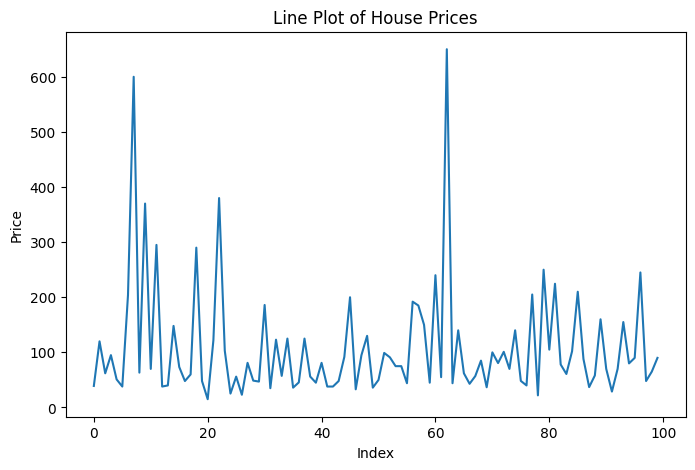

In [67]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(df["price"].head(100))
plt.title("Line Plot of House Prices")
plt.xlabel("Index")
plt.ylabel("Price")

plt.savefig("Plots/line_plot.png")
plt.show()

Bar Chart

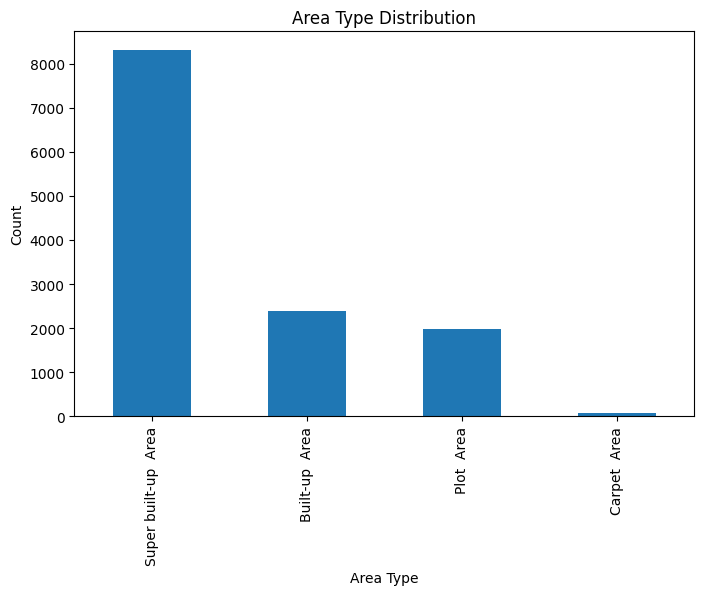

In [68]:
plt.figure(figsize=(8,5))
df["area_type"].value_counts().plot(kind="bar")

plt.title("Area Type Distribution")
plt.xlabel("Area Type")
plt.ylabel("Count")

plt.savefig("Plots/bar_plot.png")
plt.show()

Histogram

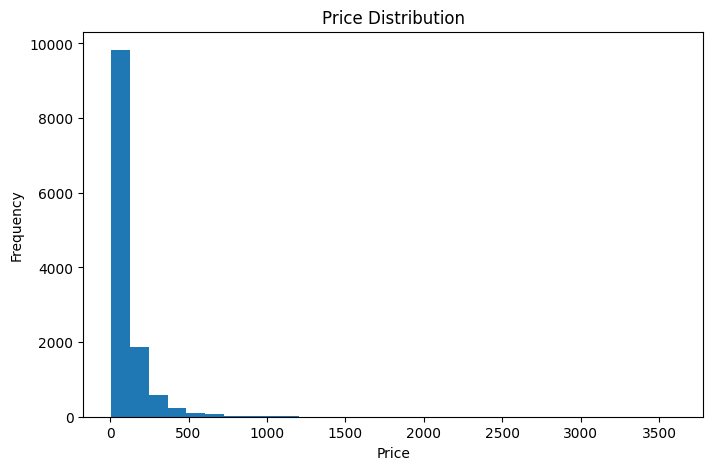

In [70]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("Plots/histogram.png")
plt.show()

scatter plot

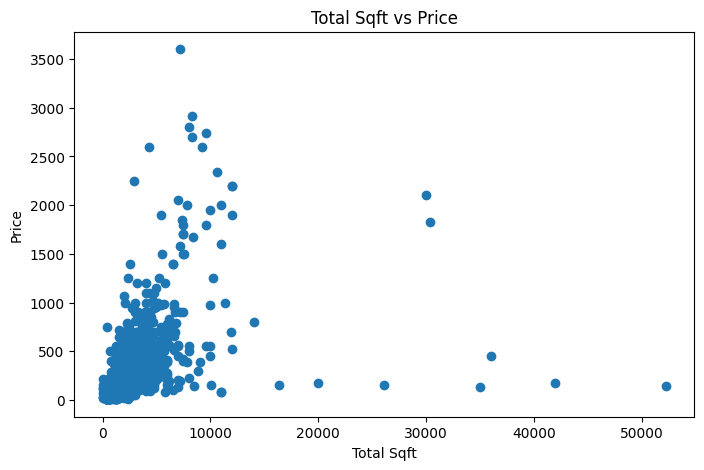

In [71]:
plt.figure(figsize=(8,5))
plt.scatter(df["total_sqft"], df["price"])

plt.title("Total Sqft vs Price")
plt.xlabel("Total Sqft")
plt.ylabel("Price")

plt.savefig("Plots/scatter_plot.png")
plt.show()

Box Plot

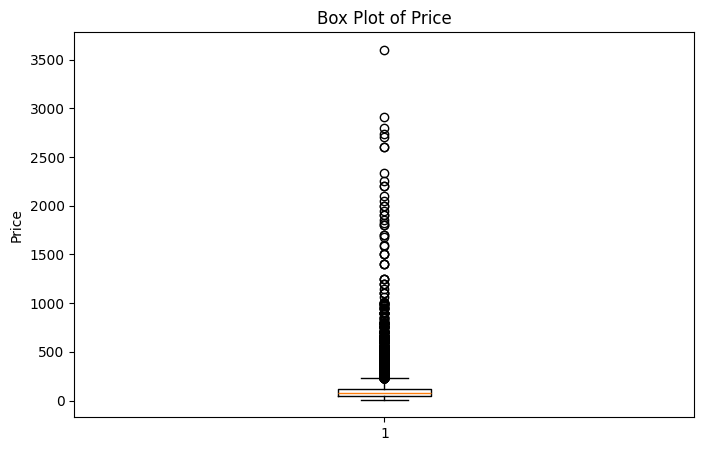

In [72]:
plt.figure(figsize=(8,5))
plt.boxplot(df["price"].dropna())

plt.title("Box Plot of Price")
plt.ylabel("Price")

plt.savefig("Plots/box_plot.png")
plt.show()

Correlation heat map

In [74]:
corr_matrix=df.select_dtypes(include=["number"]).corr(method='pearson')

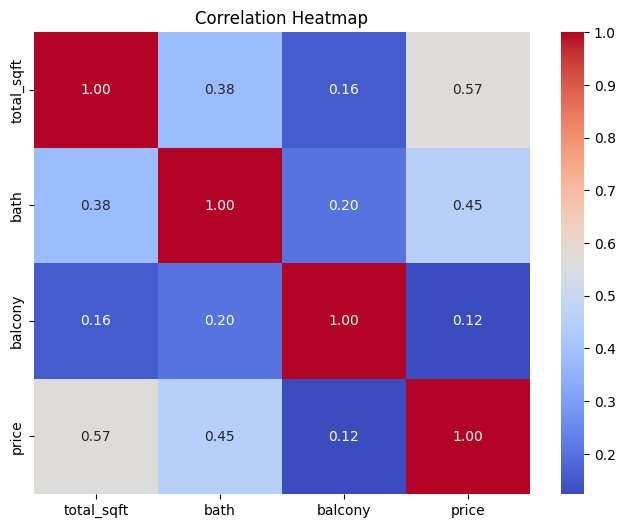

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.savefig("Plots/correlation_heatmap.png")

plt.show()

In [76]:
corr = corr_matrix.copy()

import numpy as np
np.fill_diagonal(corr.values, np.nan)

max_corr = corr.unstack().idxmax()
min_corr = corr.unstack().idxmin()

print("Strongest Positive Correlation:", max_corr)
print("Value:", corr.unstack().max())

print("Strongest Negative Correlation:", min_corr)
print("Value:", corr.unstack().min())

Strongest Positive Correlation: ('total_sqft', 'price')
Value: 0.5684045934565077
Strongest Negative Correlation: ('balcony', 'price')
Value: 0.123608303175149


9(a)-mean - median comparison

In [77]:
mean_price = df["price"].mean()
median_price = df["price"].median()

print("Mean Price:", mean_price)
print("Median Price:", median_price)

Mean Price: 114.32297458952306
Median Price: 73.0


9(b)-Spearman rank correlation. 

In [81]:
pearson_corr = df["total_sqft"].corr(df["price"], method="pearson")
spearman_corr = df["total_sqft"].corr(df["price"], method="spearman")

print("Pearson Correlation :", pearson_corr)
print("Spearman Correlation:", spearman_corr)

Pearson Correlation : 0.5684045934565017
Spearman Correlation: 0.7221533586277116


9(c)-Groupby Aggregation

In [82]:
grouped = df.groupby("area_type")["price"].agg(["mean", "median", "count"])

print(grouped)

                            mean  median  count
area_type                                      
Built-up  Area        104.822222   70.00   2397
Carpet  Area           89.502356   70.00     87
Plot  Area            210.520543  140.00   1989
Super built-up  Area   94.315248   65.31   8317


C:\Users\admin\AppData\Local\Temp\ipykernel_19540\2987013290.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("area_type")["price"].agg(["mean", "median", "count"])


10-Save the cleaned Dataset

In [83]:
df.to_csv("cleaned_data.csv", index=False)
print("Cleaned data saved to 'cleaned_data.csv'")

Cleaned data saved to 'cleaned_data.csv'
